In [ ]:
FAST_MODE = True  # Set to False when you want full training.

In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
import kagglehub


In [ ]:
path = kagglehub.dataset_download("shivamb/real-or-fake-fake-jobposting-prediction")
df = pd.read_csv(f"{path}/fake_job_postings.csv")

print(f"Dataset loaded: {df.shape}")
print(f"Fraud rate: {df['fraudulent'].mean()*100:.2f}%")


100%|██████████| 16.1M/16.1M [00:01<00:00, 9.29MB/s]

Extracting files...


Dataset loaded: (17880, 18)
Fraud rate: 4.84%


# Combine, Clean text

In [ ]:
def combine_text_fields(row):
    """Combine all text fields"""
    fields = [
        'title', 'location', 'company_profile', 'description',
        'requirements', 'benefits', 'required_experience',
        'required_education', 'industry', 'function'
    ]

    text_parts = []
    for field in fields:
        if pd.notna(row[field]):
            text_parts.append(str(row[field]))

    return ' '.join(text_parts) if text_parts else "unknown job"


def clean_text(text):
    """Clean text (38832 style)"""
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.strip()


print("Combining and cleaning text...")
df['combined_text'] = df.apply(combine_text_fields, axis=1)
df['text_cleaned'] = df['combined_text'].apply(clean_text)
print("Done")


Combining and cleaning text...
Done


# Tokenize and Pad

In [ ]:
print("Tokenizing text...")
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['text_cleaned'])

X_sequences = tokenizer.texts_to_sequences(df['text_cleaned'])

# Fast-mode friendly max length
MAX_SEQUENCE_LENGTH = 150 if FAST_MODE else 500

# Pad sequences to fixed length
X_padded = pad_sequences(
    X_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding='post',
    truncating='post'
)

y = df['fraudulent'].values
print("Done")
print(f"  Sequence shape: {X_padded.shape}")
print(f"  Vocabulary size: {len(tokenizer.word_index)}")


Tokenizing text...
Done
  Sequence shape: (17880, 500)
  Vocabulary size: 188032


# Stratified split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Train/Test Split (Stratified):")
print(f"  Train: {X_train.shape}, fraud rate: {y_train.mean()*100:.2f}%")
print(f"  Test:  {X_test.shape}, fraud rate: {y_test.mean()*100:.2f}%")


Train/Test Split (Stratified):
  Train: (12516, 500), fraud rate: 4.84%
  Test:  (5364, 500), fraud rate: 4.85%


# Class weights

In [ ]:
print("Calculating class weights instead of SMOTE...")

from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print(f"Class weights: {class_weight_dict}")

# Use original train data (NOT SMOTE)
X_train_final = X_train
y_train_final = y_train


Calculating class weights instead of SMOTE...
Class weights: {0: np.float64(0.52544080604534), 1: np.float64(10.326732673267326)}


# LSTM model

In [ ]:
print("\nBuilding LSTM model...")

EMBEDDING_DIM = 64 if FAST_MODE else 128
LSTM_UNITS = 64 if FAST_MODE else 128
DENSE_UNITS = 32 if FAST_MODE else 64

model = Sequential([
    Embedding(input_dim=10000,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_SEQUENCE_LENGTH),
    LSTM(LSTM_UNITS),
    Dropout(0.3),
    Dense(DENSE_UNITS, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print(model.summary())



Building LSTM model...


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
print("\nTraining LSTM...")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_final, y_train_final,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


print("✓ Training complete\n")



Training LSTM...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9588 - loss: 0.1534 - val_accuracy: 0.9505 - val_loss: 0.1575
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9585 - loss: 0.1268 - val_accuracy: 0.9509 - val_loss: 0.1574
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9624 - loss: 0.1076 - val_accuracy: 0.9521 - val_loss: 0.1568
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9689 - loss: 0.1003 - val_accuracy: 0.9669 - val_loss: 0.1247
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9850 - loss: 0.0613 - val_accuracy: 0.9720 - val_loss: 0.1301
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9858 - loss: 0.0530 - val_accuracy: 0.9728 - val_loss: 0.1149
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9915 - loss: 0.0318 - val_accuracy: 0.9740 - val_loss: 0.1194
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9908 - loss:

In [ ]:
print("\n" + "="*80)
print("LSTM MODEL RESULTS")
print("="*80)

y_pred_proba = model.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.4).astype(int).flatten()

print("="*80)
print("LSTM RESULTS")
print("="*80)
accuracy_lstm = accuracy_score(y_test, y_pred)
f1_lstm = f1_score(y_test, y_pred)
precision_lstm = precision_score(y_test, y_pred)
recall_lstm = recall_score(y_test, y_pred)
roc_auc_lstm = roc_auc_score(y_test, y_pred_proba)


print(f"Accuracy:  {accuracy_lstm:.4f}")
print(f"F1-Score:  {f1_lstm:.4f}")
print(f"Precision: {precision_lstm:.4f}")
print(f"Recall:    {recall_lstm:.4f}")
print(f"ROC-AUC:   {roc_auc_lstm:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


LSTM MODEL RESULTS
LSTM RESULTS
Accuracy:  0.9713
F1-Score:  0.6578
Precision: 0.7789
Recall:    0.5692
ROC-AUC:   0.8921

Confusion Matrix:
[[5062   42]
 [ 112  148]]


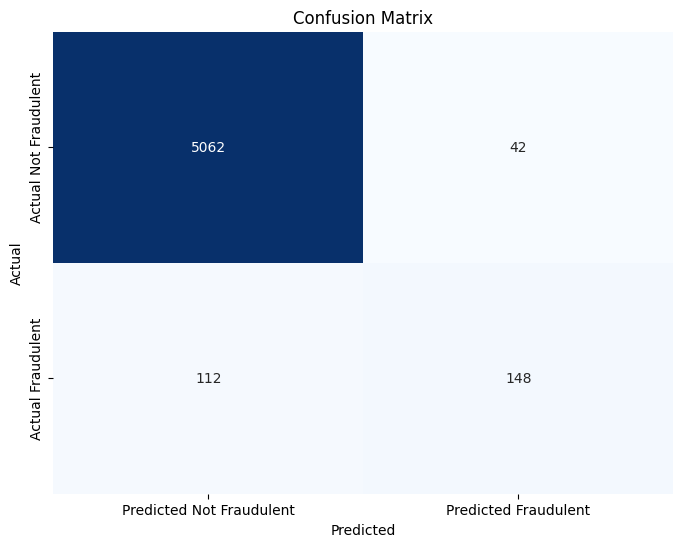

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Not Fraudulent', 'Predicted Fraudulent'],
            yticklabels=['Actual Not Fraudulent', 'Actual Fraudulent'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print("\n" + "="*80)
print("THRESHOLD OPTIMIZATION")
print("="*80)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
best_f1 = 0
best_threshold = 0.5

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    print(f"Threshold {thresh}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\n✓ Best threshold: {best_threshold} (F1={best_f1:.4f})")


THRESHOLD OPTIMIZATION
Threshold 0.3: Acc=0.9709, Prec=0.7708, Rec=0.5692, F1=0.6549
Threshold 0.4: Acc=0.9713, Prec=0.7789, Rec=0.5692, F1=0.6578
Threshold 0.5: Acc=0.9715, Prec=0.7861, Rec=0.5654, F1=0.6577
Threshold 0.6: Acc=0.9713, Prec=0.7944, Rec=0.5500, F1=0.6500
Threshold 0.7: Acc=0.9713, Prec=0.8118, Rec=0.5308, F1=0.6419

✓ Best threshold: 0.4 (F1=0.6578)


In [ ]:
print("\n" + "="*80)
print("WEEK 1 vs WEEK 2 COMPARISON")
print("="*80)

comparison = pd.DataFrame({
    'Model': ['Naïve Bayes (Week 1)', 'LSTM (Week 2)'],
    'Accuracy': [0.9702, accuracy_lstm],
    'F1-Score': [0.5960, f1_lstm],
    'Precision': [0.8676, precision_lstm],
    'Recall': [0.4538, recall_lstm],
    'ROC-AUC': [0.7234, roc_auc_lstm]
})

print(comparison.to_string(index=False))


WEEK 1 vs WEEK 2 COMPARISON
               Model  Accuracy  F1-Score  Precision   Recall  ROC-AUC
Naïve Bayes (Week 1)  0.970200  0.596000   0.867600 0.453800 0.723400
       LSTM (Week 2)  0.971477  0.657718   0.786096 0.565385 0.892132
